# 02 成長傾向・変化分析

## 目的

ブロイラー鶏舎の自動計量データから作成した日次集計データを用いて、
飼育期間中のプラットフォーム荷重の変化を分析する。

Trial・Penごとの推移や前日からの変化を比較し、
通常の成長傾向とは異なる大きな変化がみられる日を抽出する。

## 分析内容

- Trial 1・Trial 2の日次集計データの作成
- Penごとのプラットフォーム荷重の推移
- 前日からの変化量・変化率
- Pen間の比較
- 大きな変化が発生した日の抽出
- 変化が特定Penのみか、複数Pen共通かを確認

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..")

trial1 = pd.read_csv(
    PROJECT_ROOT / "data" / "interim" / "trial1_daily_quality_summary.csv",
    parse_dates=["date"]
)

trial2 = pd.read_csv(
    PROJECT_ROOT / "data" / "interim" / "trial2_daily_quality_summary.csv",
    parse_dates=["date"]
)

print("Trial 1:", trial1.shape)
print("Trial 2:", trial2.shape)

display(trial1.head())
display(trial2.head())

Trial 1: (102, 7)
Trial 2: (107, 7)


,date,pen,count,min_mass,median_mass,max_mass,over_10kg
0,2019-06-19,1,546957,-0.43,-0.30,82.15,1166
1,2019-06-19,2,546949,-0.37,-0.22,-0.13,0
2,2019-06-19,3,546539,-0.52,-0.27,-0.05,0
3,2019-06-20,1,789613,-0.47,-0.34,-0.10,0
4,2019-06-20,2,789672,-0.41,-0.25,-0.08,0


,date,pen,count,min_mass,median_mass,max_mass,over_10kg
0,2019-09-09,1,773,0.04,0.04,0.05,0
1,2019-09-09,2,364701,-0.13,-0.10,0.01,0
2,2019-09-09,3,357071,-0.15,-0.11,0.16,0
3,2019-09-10,1,606604,-0.37,-0.19,8.12,0
4,2019-09-10,2,841123,-0.20,-0.09,0.05,0


In [3]:
# Trial名を付けて結合
trial1["trial"] = "Trial 1"
trial2["trial"] = "Trial 2"

daily = pd.concat([trial1, trial2], ignore_index=True)

# Trial・Pen・日付順に並べる
daily = daily.sort_values(
    ["trial", "pen", "date"]
).reset_index(drop=True)

# 前日からの中央値の変化量
daily["median_change"] = (
    daily.groupby(["trial", "pen"])["median_mass"].diff()
)

display(
    daily[
        ["trial", "date", "pen", "median_mass", "median_change"]
    ].head(15)
)

,trial,date,pen,median_mass,median_change
0,Trial 1,2019-06-19,1,-0.30,NaN
1,Trial 1,2019-06-20,1,-0.34,-0.04
2,Trial 1,2019-06-21,1,-0.23,0.11
3,Trial 1,2019-06-22,1,-0.12,0.11
4,Trial 1,2019-06-23,1,0.31,0.43
5,Trial 1,2019-06-24,1,0.71,0.40
6,Trial 1,2019-06-25,1,0.45,-0.26
7,Trial 1,2019-06-26,1,2.29,1.84
8,Trial 1,2019-06-27,1,34.67,32.38
9,Trial 1,2019-06-28,1,10.10,-24.57


In [4]:
# 前日差の絶対値
daily["abs_median_change"] = daily["median_change"].abs()

# 変化が大きかった順に確認
large_changes = (
    daily
    .dropna(subset=["median_change"])
    .sort_values("abs_median_change", ascending=False)
)

display(
    large_changes[
        [
            "trial",
            "date",
            "pen",
            "median_mass",
            "median_change",
            "abs_median_change"
        ]
    ].head(20)
)

,trial,date,pen,median_mass,median_change,abs_median_change
8,Trial 1,2019-06-27,1,34.67,32.38,32.38
9,Trial 1,2019-06-28,1,10.10,-24.57,24.57
14,Trial 1,2019-07-03,1,54.55,23.55,23.55
29,Trial 1,2019-07-18,1,77.69,-17.33,17.33
101,Trial 1,2019-07-22,3,69.10,15.74,15.74
46,Trial 1,2019-07-01,2,19.71,14.13,14.13
80,Trial 1,2019-07-01,3,21.84,13.86,13.86
13,Trial 1,2019-07-02,1,31.00,13.25,13.25
63,Trial 1,2019-07-18,2,63.04,-13.17,13.17
92,Trial 1,2019-07-13,3,59.41,12.03,12.03


In [5]:
# 探索用の暫定しきい値
threshold = 8

daily["large_change_flag"] = (
    daily["abs_median_change"] >= threshold
)

# 日付ごとに、大きな変化があったPen数を集計
daily_change_summary = (
    daily
    .groupby(["trial", "date"])
    .agg(
        large_change_pens=("large_change_flag", "sum"),
        max_abs_change=("abs_median_change", "max")
    )
    .reset_index()
)

display(
    daily_change_summary[
        daily_change_summary["large_change_pens"] > 0
    ].sort_values(
        ["large_change_pens", "max_abs_change"],
        ascending=False
    )
)

,trial,date,large_change_pens,max_abs_change
29,Trial 1,2019-07-18,3,17.33
33,Trial 1,2019-07-22,3,15.74
12,Trial 1,2019-07-01,3,14.13
31,Trial 1,2019-07-20,3,11.87
8,Trial 1,2019-06-27,2,32.38
13,Trial 1,2019-07-02,2,13.25
24,Trial 1,2019-07-13,2,12.03
9,Trial 1,2019-06-28,1,24.57
14,Trial 1,2019-07-03,1,23.55
60,Trial 2,2019-10-05,1,10.38


In [6]:
change_stats = (
    daily
    .groupby("trial")["abs_median_change"]
    .describe(
        percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]
    )
)

display(change_stats)

,count,mean,std,min,25%,50%,75%,90%,95%,max
trial,,,,,,,,,,
Trial 1,99.0,4.856970,5.754647,0.01,1.0400,2.500,6.8550,11.902,14.291,32.38
Trial 2,104.0,2.691971,2.438121,0.00,0.7725,2.085,4.2475,6.016,6.910,10.38


In [7]:
# Trialごとの前日差の95%点を計算
thresholds = (
    daily
    .groupby("trial")["abs_median_change"]
    .quantile(0.95)
)

display(thresholds)

trial
Trial 1    14.291
Trial 2     6.910
Name: abs_median_change, dtype: float64

In [8]:
# Trialごとの95%点を各行に付与
daily["change_threshold"] = (
    daily["trial"].map(thresholds)
)

# 95%点以上を大きな変化候補とする
daily["change_candidate"] = (
    daily["abs_median_change"] >= daily["change_threshold"]
)

candidates = daily[
    daily["change_candidate"]
][
    [
        "trial",
        "date",
        "pen",
        "median_mass",
        "median_change",
        "abs_median_change",
        "change_threshold"
    ]
]

display(candidates)

,trial,date,pen,median_mass,median_change,abs_median_change,change_threshold
8,Trial 1,2019-06-27,1,34.67,32.38,32.38,14.291
9,Trial 1,2019-06-28,1,10.10,-24.57,24.57,14.291
14,Trial 1,2019-07-03,1,54.55,23.55,23.55,14.291
29,Trial 1,2019-07-18,1,77.69,-17.33,17.33,14.291
101,Trial 1,2019-07-22,3,69.10,15.74,15.74,14.291
118,Trial 2,2019-09-25,1,20.29,6.94,6.94,6.910
160,Trial 2,2019-10-01,2,42.98,8.12,8.12,6.910
163,Trial 2,2019-10-05,2,56.37,10.38,10.38,6.910
167,Trial 2,2019-10-09,2,69.51,9.19,9.19,6.910
171,Trial 2,2019-10-13,2,72.93,10.19,10.19,6.910


### 前日変化量による確認候補日の抽出

各Penの日次中央値について、前日との差（median_change）と
その絶対値（abs_median_change）を算出した。

前日変化量の分布をTrialごとに確認したところ、
Trial 1はTrial 2よりも日々の変動が大きい傾向がみられた。

そのため、全Trialで共通の固定値を基準とするのではなく、
各Trialの前日変化量の95%点を暫定的なしきい値として使用した。

- Trial 1：14.291 kg
- Trial 2：6.910 kg

この基準を超えるデータを、
通常より大きな変化がみられた「確認候補」として抽出した。

なお、95%点は異常を確定する基準ではなく、
モニタリング上で詳細確認するデータを絞り込むための探索的な基準として使用する。

In [20]:
def plot_growth_with_candidates(data, trial_name, save_path=None):
    trial_data = data[data["trial"] == trial_name]

    plt.figure(figsize=(12, 6))

    for pen in sorted(trial_data["pen"].unique()):
        pen_data = trial_data[trial_data["pen"] == pen]

        plt.plot(
            pen_data["date"],
            pen_data["median_mass"],
            marker="o",
            markersize=3,
            label=f"Pen {pen}"
        )

    candidate_data = trial_data[
        trial_data["change_candidate"]
    ]

    plt.scatter(
        candidate_data["date"],
        candidate_data["median_mass"],
        s=120,
        marker="X",
        label="Large daily change",
        zorder=5
    )

    plt.xlabel("Date")
    plt.ylabel("Median platform mass [kg]")
    plt.title(
        f"Daily median platform mass and large daily changes - {trial_name}"
    )

    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(alpha=0.3)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()

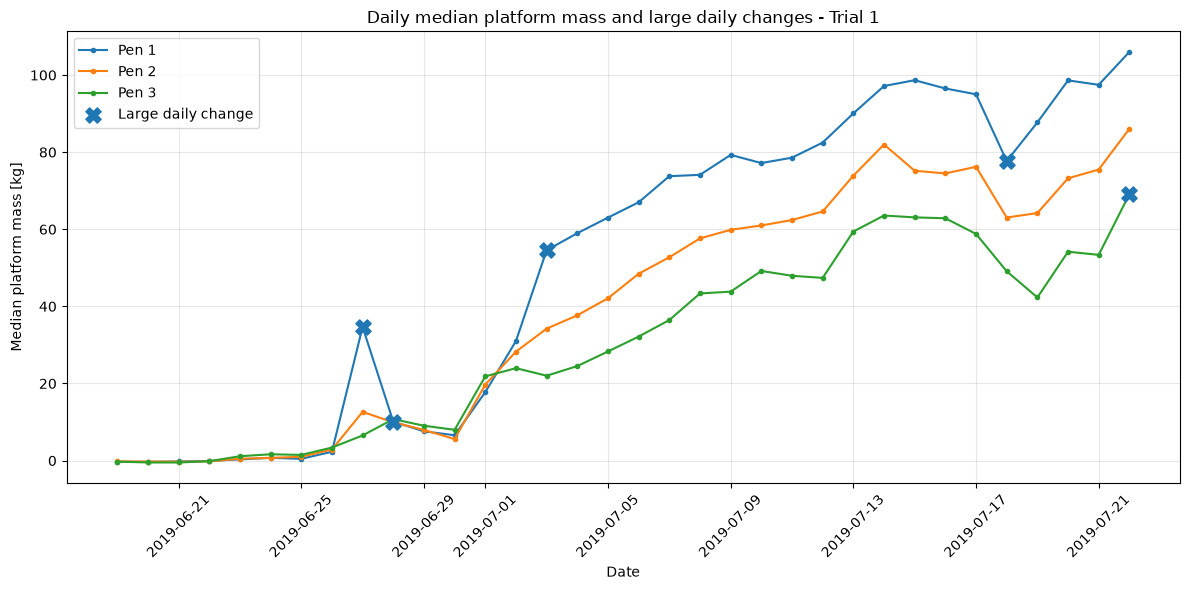

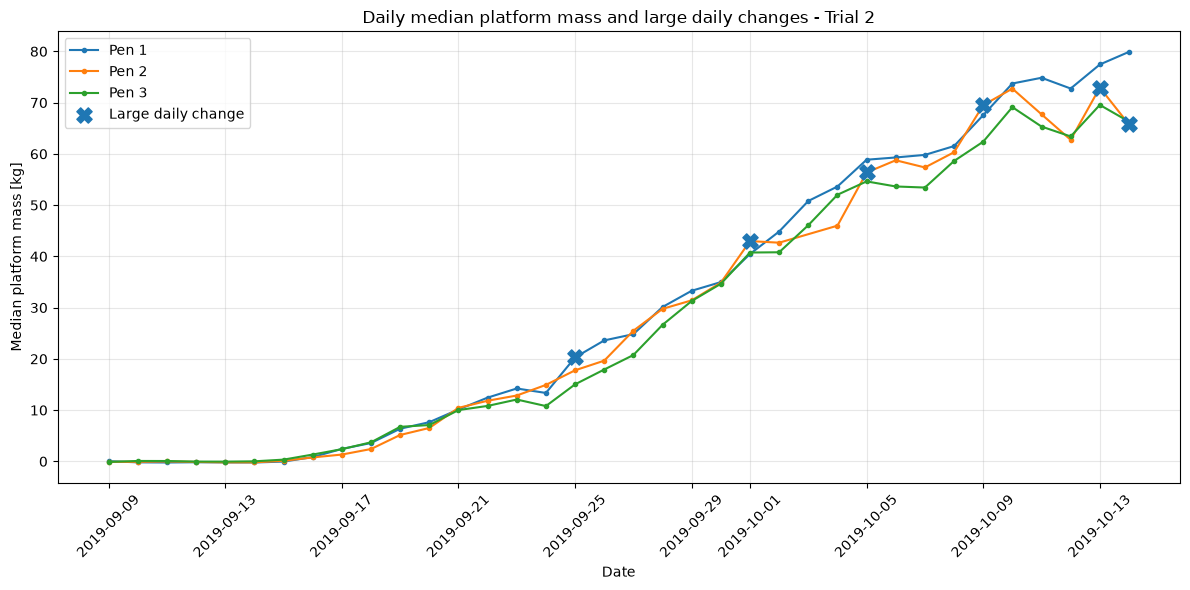

In [21]:
plot_growth_with_candidates(
    daily,
    "Trial 1",
    PROJECT_ROOT / "images" / "trial1_growth_changes.png"
)

plot_growth_with_candidates(
    daily,
    "Trial 2",
    PROJECT_ROOT / "images" / "trial2_growth_changes.png"
)

### 成長曲線と確認候補の可視化

TrialごとにPen別の日次中央値を成長曲線として可視化し、
前日変化量が各Trialの95%点以上となったデータを確認候補として表示した。

#### Trial 1
- 全体として期間の経過とともに中央値は上昇した。
- Pen間の差が大きく、特にPen 1は高い値で推移した。
- 6月下旬にはPen 1で急激な上昇と低下が連続して確認された。
- 7月中旬以降にも大きな変化がみられ、通常の成長傾向とは異なる変動が確認された。

#### Trial 2
- 3つのPenが比較的近い値で推移し、全体として滑らかな上昇傾向を示した。
- 確認候補となる変化は存在するものの、Trial 1のような極端な上下動はみられなかった。

以上から、Trial間で日々の変動幅やPen間のばらつきに違いがあることが確認できた。

In [11]:
# 日付ごとのPen間差を計算
pen_spread = (
    daily
    .groupby(["trial", "date"])
    .agg(
        min_pen_mass=("median_mass", "min"),
        max_pen_mass=("median_mass", "max"),
        pen_count=("pen", "nunique")
    )
    .reset_index()
)

# 最大Pen - 最小Pen
pen_spread["pen_spread"] = (
    pen_spread["max_pen_mass"] - pen_spread["min_pen_mass"]
)

display(pen_spread.head(10))

,trial,date,min_pen_mass,max_pen_mass,pen_count,pen_spread
0,Trial 1,2019-06-19,-0.30,-0.22,3,0.08
1,Trial 1,2019-06-20,-0.49,-0.25,3,0.24
2,Trial 1,2019-06-21,-0.50,-0.23,3,0.27
3,Trial 1,2019-06-22,-0.21,-0.12,3,0.09
4,Trial 1,2019-06-23,0.31,1.13,3,0.82
5,Trial 1,2019-06-24,0.70,1.63,3,0.93
6,Trial 1,2019-06-25,0.45,1.47,3,1.02
7,Trial 1,2019-06-26,2.29,3.37,3,1.08
8,Trial 1,2019-06-27,6.52,34.67,3,28.15
9,Trial 1,2019-06-28,9.92,10.75,3,0.83


In [12]:
display(
    pen_spread
    .groupby("trial")["pen_spread"]
    .describe()
)

,count,mean,std,min,25%,50%,75%,max
trial,,,,,,,,
Trial 1,34.0,22.103824,16.896127,0.08,1.1725,30.640,35.0425,45.410
Trial 2,36.0,3.570972,3.379734,0.13,0.5275,2.715,5.3600,14.165


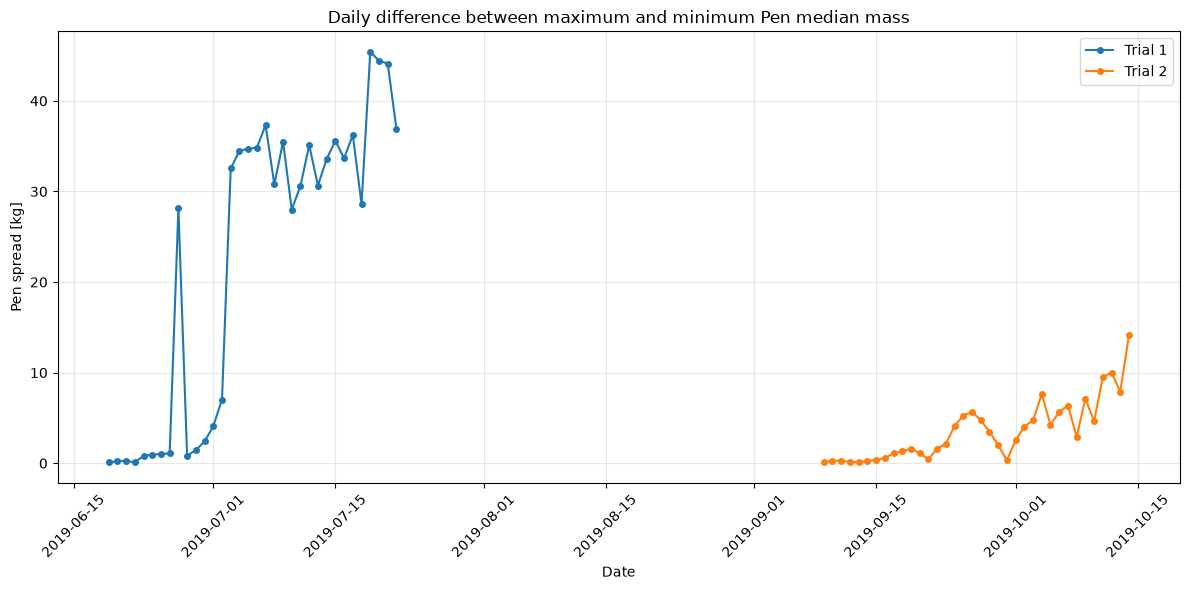

In [13]:
plt.figure(figsize=(12, 6))

for trial in ["Trial 1", "Trial 2"]:
    trial_data = pen_spread[
        pen_spread["trial"] == trial
    ]

    plt.plot(
        trial_data["date"],
        trial_data["pen_spread"],
        marker="o",
        markersize=4,
        label=trial
    )

plt.xlabel("Date")
plt.ylabel("Pen spread [kg]")
plt.title("Daily difference between maximum and minimum Pen median mass")
plt.legend()
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Pen間差の比較

同一日におけるPen間のばらつきを確認するため、
各日のPen別中央値について「最大値 - 最小値」をPen間差として算出した。

#### Trial 1
- Pen間差の平均：22.10 kg
- 中央値：30.64 kg
- 最大：45.41 kg
- 飼育期間の序盤はPen間差が小さかったが、途中から差が大きくなり、
  期間後半では30〜45 kg程度の差が継続してみられた。

#### Trial 2
- Pen間差の平均：3.57 kg
- 中央値：2.72 kg
- 最大：14.17 kg
- Trial 1と比較してPen間差は小さく、3つのPenが比較的近い推移を示した。
- 期間後半ではPen間差がやや拡大する傾向もみられた。

以上から、Trial 1ではTrial 2と比較して、
Pen間のプラットフォーム荷重の差が大きいことが確認された。

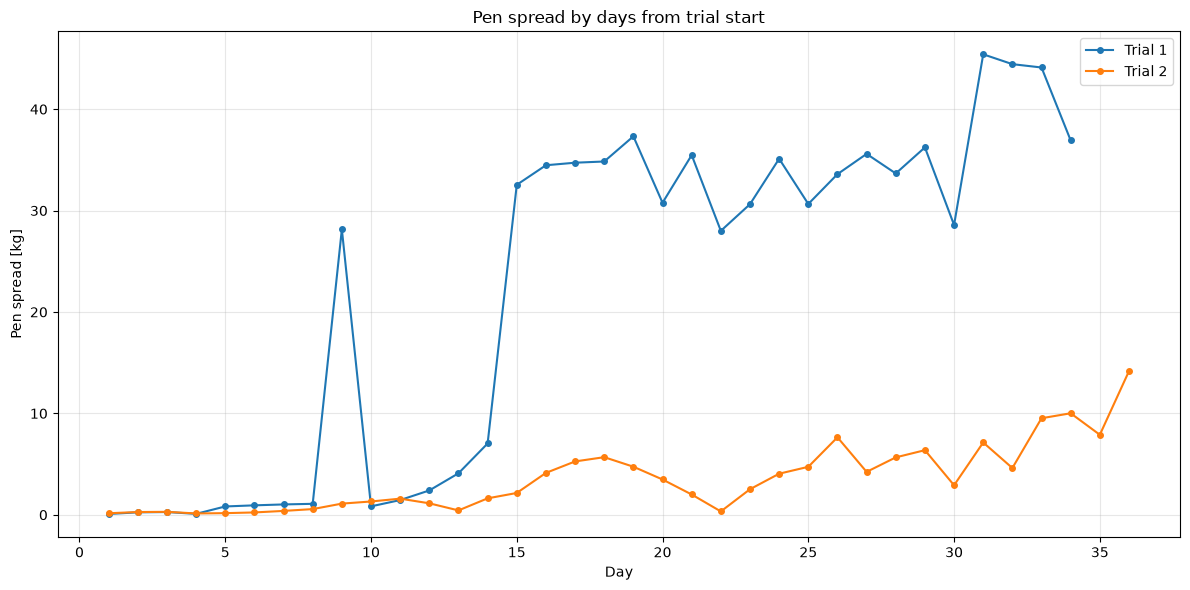

In [22]:
# Trialごとに飼育開始からの日数を作成
pen_spread["day"] = (
    pen_spread
    .groupby("trial")["date"]
    .transform(lambda x: (x - x.min()).dt.days + 1)
)

plt.figure(figsize=(12, 6))

for trial in ["Trial 1", "Trial 2"]:
    trial_data = pen_spread[
        pen_spread["trial"] == trial
    ]

    plt.plot(
        trial_data["day"],
        trial_data["pen_spread"],
        marker="o",
        markersize=4,
        label=trial
    )

plt.xlabel("Day")
plt.ylabel("Pen spread [kg]")
plt.title("Pen spread by days from trial start")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    PROJECT_ROOT / "images" / "pen_spread_comparison.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [16]:
# Pen間差の前日からの変化量
pen_spread["spread_change"] = (
    pen_spread
    .groupby("trial")["pen_spread"]
    .diff()
)

# 増加が大きかった順に確認
spread_increase = (
    pen_spread
    .dropna(subset=["spread_change"])
    .sort_values("spread_change", ascending=False)
)

display(
    spread_increase[
        [
            "trial",
            "date",
            "day",
            "pen_spread",
            "spread_change"
        ]
    ].head(15)
)

,trial,date,day,pen_spread,spread_change
8,Trial 1,2019-06-27,9,28.150,27.070
14,Trial 1,2019-07-03,15,32.540,25.510
30,Trial 1,2019-07-19,31,45.410,16.830
69,Trial 2,2019-10-14,36,14.165,6.275
66,Trial 2,2019-10-11,33,9.520,4.910
20,Trial 1,2019-07-09,21,35.470,4.700
23,Trial 1,2019-07-12,24,35.110,4.480
64,Trial 2,2019-10-09,31,7.130,4.220
13,Trial 1,2019-07-02,14,7.030,2.940
25,Trial 1,2019-07-14,26,33.590,2.940


In [17]:
# Trial 1のDay 7〜20を確認
display(
    pen_spread[
        (pen_spread["trial"] == "Trial 1") &
        (pen_spread["day"].between(7, 20))
    ][
        [
            "date",
            "day",
            "pen_spread",
            "spread_change"
        ]
    ]
)

,date,day,pen_spread,spread_change
6,2019-06-25,7,1.02,0.09
7,2019-06-26,8,1.08,0.06
8,2019-06-27,9,28.15,27.07
9,2019-06-28,10,0.83,-27.32
10,2019-06-29,11,1.45,0.62
11,2019-06-30,12,2.40,0.95
12,2019-07-01,13,4.09,1.69
13,2019-07-02,14,7.03,2.94
14,2019-07-03,15,32.54,25.51
15,2019-07-04,16,34.47,1.93


### 一時的な変化と継続的なPen間差

Trial 1についてPen間差が急激に拡大した日を確認したところ、
異なる2種類の変化がみられた。

- Day 9ではPen間差が1.08 kgから28.15 kgへ急拡大したが、
  翌日には0.83 kgまで縮小した。
  この変化は一時的な乖離と考えられる。

- Day 15ではPen間差が7.03 kgから32.54 kgへ急拡大した。
  その後もDay 16〜20では30 kg以上のPen間差が継続しており、
  一時的な変化ではなく、Pen間の差が継続する状態へ移行したことが確認された。

このことから、前日からの変化量だけではなく、
変化後の状態が複数日にわたって継続しているかを確認することで、
一時的な変動と継続的な状態変化を区別できる可能性がある。

## モニタリング指標の検討

ここまでの分析結果から、プラットフォーム荷重の推移を確認するため、
以下の2つの指標をモニタリングに利用できる可能性がある。

### 1. Penごとの前日変化量

各Penの日次中央値について前日との差を算出する。

前日変化量が通常より大きい場合、
急激な荷重変化が発生した確認候補として抽出する。

本分析ではTrialごとに変動幅が異なっていたため、
前日変化量の絶対値の95%点を探索的なしきい値として使用した。

### 2. Pen間差

同一日におけるPen別中央値の最大値と最小値の差を算出する。

Pen間差が大きくなることで、
同じTrial内でもPenごとの推移が乖離している状態を把握できる。

また、Pen間差が急激に拡大した場合でも、
翌日に元の水準へ戻るケースと、
大きな差が複数日にわたって継続するケースが確認された。

そのため、Pen間差の大きさだけではなく、
変化後の状態が継続しているかを併せて確認することが重要と考えられる。

In [18]:
# 日ごとの変化候補Pen数
monitoring_summary = (
    daily
    .groupby(["trial", "date"])
    .agg(
        change_candidate_pens=("change_candidate", "sum")
    )
    .reset_index()
)

# Pen間差を結合
monitoring_summary = monitoring_summary.merge(
    pen_spread[
        ["trial", "date", "day", "pen_spread", "spread_change"]
    ],
    on=["trial", "date"],
    how="left"
)

display(monitoring_summary.head(10))

,trial,date,change_candidate_pens,day,pen_spread,spread_change
0,Trial 1,2019-06-19,0,1,0.08,NaN
1,Trial 1,2019-06-20,0,2,0.24,0.16
2,Trial 1,2019-06-21,0,3,0.27,0.03
3,Trial 1,2019-06-22,0,4,0.09,-0.18
4,Trial 1,2019-06-23,0,5,0.82,0.73
5,Trial 1,2019-06-24,0,6,0.93,0.11
6,Trial 1,2019-06-25,0,7,1.02,0.09
7,Trial 1,2019-06-26,0,8,1.08,0.06
8,Trial 1,2019-06-27,1,9,28.15,27.07
9,Trial 1,2019-06-28,1,10,0.83,-27.32


In [19]:
# 前日変化量から確認候補となった日を抽出
monitoring_candidates = (
    monitoring_summary[
        monitoring_summary["change_candidate_pens"] > 0
    ]
    .sort_values(["trial", "date"])
    .reset_index(drop=True)
)

display(monitoring_candidates)

,trial,date,change_candidate_pens,day,pen_spread,spread_change
0,Trial 1,2019-06-27,1,9,28.150,27.070
1,Trial 1,2019-06-28,1,10,0.830,-27.320
2,Trial 1,2019-07-03,1,15,32.540,25.510
3,Trial 1,2019-07-18,1,30,28.580,-7.650
4,Trial 1,2019-07-22,1,34,36.920,-7.190
5,Trial 2,2019-09-25,1,17,5.260,1.130
6,Trial 2,2019-10-01,1,23,2.520,2.190
7,Trial 2,2019-10-05,1,27,4.230,-3.410
8,Trial 2,2019-10-09,1,31,7.130,4.220
9,Trial 2,2019-10-13,1,35,7.890,-2.120


## 分析結果まとめ

本分析では、日次のプラットフォーム荷重データから、
飼育期間中の変化を把握するためのモニタリング指標を検討した。

### 1. Penごとの前日変化

Penごとの日次中央値から前日変化量を算出したところ、
Trial 1はTrial 2より日々の変動幅が大きいことが確認された。

Trialごとの変動幅の違いを考慮するため、
前日変化量の絶対値について各Trialの95%点を探索的なしきい値とし、
通常より大きな変化がみられた日を確認候補として抽出した。

その結果、
- Trial 1：5日
- Trial 2：6日

が確認候補となった。

### 2. Pen間差

同一日のPen別中央値について「最大値 - 最小値」を算出し、
Pen間の乖離を確認した。

Trial 1ではTrial 2と比較してPen間差が大きく、
期間後半では30kg以上の差が継続してみられた。
一方、Trial 2では3つのPenが比較的近い推移を示した。

### 3. 一時的な変化と継続的な変化

Trial 1では、Pen間差が急激に拡大しても翌日に元の水準へ戻るケースと、
拡大後も大きな差が複数日にわたって継続するケースの両方が確認された。

このことから、単日の変化量だけでなく、
変化後の状態が継続しているかを確認することも重要と考えられる。

## モニタリングへの活用

今回の分析から、

- Penごとの急激な前日変化
- Pen間の乖離
- 乖離状態の継続

を組み合わせることで、
通常とは異なる推移を示す日や期間を自動的に絞り込める可能性が示された。

本分析で使用した95%点は異常を確定する基準ではなく、
詳細確認が必要なデータを絞り込むための探索的なしきい値である。

実際の運用では、飼育管理情報やセンサーの状態などと併せて確認し、
しきい値の妥当性を検証する必要がある。